In [33]:
import pandas as pd
import numpy as np
%matplotlib inline
from sklearn.model_selection import RepeatedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, accuracy_score
from xgboost import XGBClassifier
from skopt import gp_minimize
np.set_printoptions(precision=2)

# Leitura e Preparação dos Dados

In [2]:
train = pd.read_csv('./dataset/train.csv')
test = pd.read_csv('./dataset/test.csv')
print(f'Train set shape: {train.shape}\nTest set shape: {test.shape}')

Train set shape: (891, 12)
Test set shape: (418, 11)


In [3]:
train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
train['Embarked'].value_counts()

Embarked
S    644
C    168
Q     77
Name: count, dtype: int64

In [5]:
train['Sex_b'] = train['Sex'].map(lambda x: 1 if x == 'female' else 0)
test['Sex_b'] = test['Sex'].map(lambda x: 1 if x == 'female' else 0)

In [6]:
train['Sex_b'].value_counts()

Sex_b
0    577
1    314
Name: count, dtype: int64

In [7]:
train['Ticket']

0             A/5 21171
1              PC 17599
2      STON/O2. 3101282
3                113803
4                373450
             ...       
886              211536
887              112053
888          W./C. 6607
889              111369
890              370376
Name: Ticket, Length: 891, dtype: object

In [8]:
train['Name'].value_counts()

Name
Braund, Mr. Owen Harris                     1
Boulos, Mr. Hanna                           1
Frolicher-Stehli, Mr. Maxmillian            1
Gilinski, Mr. Eliezer                       1
Murdlin, Mr. Joseph                         1
                                           ..
Kelly, Miss. Anna Katherine "Annie Kate"    1
McCoy, Mr. Bernard                          1
Johnson, Mr. William Cahoone Jr             1
Keane, Miss. Nora A                         1
Dooley, Mr. Patrick                         1
Name: count, Length: 891, dtype: int64

In [9]:
train['Embarked_S'] = (train['Embarked'] == 'S').astype(int)
train['Embarked_C'] = (train['Embarked'] == 'C').astype(int)

train['Cabin_null'] = train['Cabin'].isnull().astype(int)
train['Cabin_C'] = train['Cabin'].fillna('').str.count('C').astype(int)
train['Cabin_E'] = train['Cabin'].fillna('').str.count('E').astype(int)
train['Cabin_G'] = train['Cabin'].fillna('').str.count('G').astype(int)
train['Cabin_D'] = train['Cabin'].fillna('').str.count('D').astype(int)
train['Cabin_A'] = train['Cabin'].fillna('').str.count('A').astype(int)
train['Cabin_B'] = train['Cabin'].fillna('').str.count('B').astype(int)
train['Cabin_F'] = train['Cabin'].fillna('').str.count('F').astype(int)
train['Cabin_T'] = train['Cabin'].fillna('').str.count('T').astype(int)

train['Name_Miss'] = train['Name'].str.contains('Miss.').astype(int)
train['Name_Mrs'] = train['Name'].str.contains('Mrs.').astype(int)
train['Name_Master'] = train['Name'].str.contains('Master.').astype(int)
train['Name_Col'] = train['Name'].str.contains('Col.').astype(int)
train['Name_Major'] = train['Name'].str.contains('Major.').astype(int)
train['Name_Mr'] = train['Name'].str.contains('Mr.').astype(int)
train['Name_Dr'] = train['Name'].str.contains('Dr.').astype(int)
train['Name_Don'] = train['Name'].str.contains('Don.').astype(int)
train['Name_Sir'] = train['Name'].str.contains('Sir.').astype(int)

train['Ticket_cat'] = train['Ticket'].map(lambda x: list(train['Ticket'].unique()).index(x) if x in list(train['Ticket'].unique()) else 0)
train['Ticket_num'] = train['Ticket'].str.split().map(lambda x: x[1] if len(x) > 1 and x[1].isnumeric() else x[0] if x[0].isnumeric() else 0)

In [10]:
test['Embarked_S'] = (test['Embarked'] == 'S').astype(int)
test['Embarked_C'] = (test['Embarked'] == 'C').astype(int)

test['Cabin_null'] = test['Cabin'].isnull().astype(int)
test['Cabin_C'] = test['Cabin'].fillna('').str.count('C').astype(int)
test['Cabin_E'] = test['Cabin'].fillna('').str.count('E').astype(int)
test['Cabin_G'] = test['Cabin'].fillna('').str.count('G').astype(int)
test['Cabin_D'] = test['Cabin'].fillna('').str.count('D').astype(int)
test['Cabin_A'] = test['Cabin'].fillna('').str.count('A').astype(int)
test['Cabin_B'] = test['Cabin'].fillna('').str.count('B').astype(int)
test['Cabin_F'] = test['Cabin'].fillna('').str.count('F').astype(int)
test['Cabin_T'] = test['Cabin'].fillna('').str.count('T').astype(int)

test['Name_Miss'] = test['Name'].str.contains('Miss.').astype(int)
test['Name_Mrs'] = test['Name'].str.contains('Mrs.').astype(int)
test['Name_Master'] = test['Name'].str.contains('Master.').astype(int)
test['Name_Col'] = test['Name'].str.contains('Col.').astype(int)
test['Name_Major'] = test['Name'].str.contains('Major.').astype(int)
test['Name_Mr'] = test['Name'].str.contains('Mr.').astype(int)
test['Name_Dr'] = test['Name'].str.contains('Dr.').astype(int)
test['Name_Don'] = test['Name'].str.contains('Don.').astype(int)
test['Name_Sir'] = test['Name'].str.contains('Sir.').astype(int)

test['Ticket_cat'] = test['Ticket'].map(lambda x: list(test['Ticket'].unique()).index(x) if x in list(test['Ticket'].unique()) else 0)
test['Ticket_num'] = test['Ticket'].str.split().map(lambda x: x[1] if len(x) > 1 and x[1].isnumeric() else x[0] if x[0].isnumeric() else 0)

In [11]:
variaveis = ['Sex_b', 'Age', 'Pclass', 'Embarked_S', 'Embarked_C', 'SibSp', 'Parch', 'Fare', 'Cabin_null',
             'Cabin_C', 'Cabin_E', 'Cabin_G', 'Cabin_D', 'Cabin_A', 'Cabin_B', 'Cabin_F', 'Cabin_T',
             'Name_Miss', 'Name_Mrs', 'Name_Master', 'Name_Col', 'Name_Major', 'Name_Mr', 'Name_Dr', 'Name_Don',
             'Name_Sir', 'Ticket_num', 'Ticket_cat']

In [12]:
X = train[variaveis].fillna(0)
X_test = test[variaveis].fillna(0)
y = train['Survived']

In [13]:
#X = pd.get_dummies(data=X, prefix=['Ticket_cat'], columns=['Ticket_cat'], dtype=int).drop(columns=['Ticket_cat_0'], axis=0)
X

,Sex_b,Age,Pclass,Embarked_S,Embarked_C,SibSp,Parch,Fare,Cabin_null,Cabin_C,...,Name_Mrs,Name_Master,Name_Col,Name_Major,Name_Mr,Name_Dr,Name_Don,Name_Sir,Ticket_num,Ticket_cat
0,0,22.0,3,1,0,1,0,7.2500,1,0,...,0,0,0,0,1,0,0,0,21171,0
1,1,38.0,1,0,1,1,0,71.2833,0,1,...,1,0,0,0,1,0,0,0,17599,1
2,1,26.0,3,1,0,0,0,7.9250,1,0,...,0,0,0,0,0,0,0,0,3101282,2
3,1,35.0,1,1,0,1,0,53.1000,0,1,...,1,0,0,0,1,0,0,0,113803,3
4,0,35.0,3,1,0,0,0,8.0500,1,0,...,0,0,0,0,1,0,0,0,373450,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,27.0,2,1,0,0,0,13.0000,1,0,...,0,0,0,0,0,0,0,0,211536,677
887,1,19.0,1,1,0,0,0,30.0000,0,0,...,0,0,0,0,0,0,0,0,112053,678
888,1,0.0,3,1,0,1,2,23.4500,1,0,...,0,0,0,0,0,0,0,0,6607,614
889,0,26.0,1,0,1,0,0,30.0000,0,1,...,0,0,0,0,1,0,0,0,111369,679


In [14]:
#X_test = pd.get_dummies(data=X_test, prefix=['Ticket_cat'], columns=['Ticket_cat'], dtype=int).drop(columns=['Ticket_cat_0'], axis=0)
X_test

,Sex_b,Age,Pclass,Embarked_S,Embarked_C,SibSp,Parch,Fare,Cabin_null,Cabin_C,...,Name_Mrs,Name_Master,Name_Col,Name_Major,Name_Mr,Name_Dr,Name_Don,Name_Sir,Ticket_num,Ticket_cat
0,0,34.5,3,0,0,0,0,7.8292,1,0,...,0,0,0,0,1,0,0,0,330911,0
1,1,47.0,3,1,0,1,0,7.0000,1,0,...,1,0,0,0,1,0,0,0,363272,1
2,0,62.0,2,0,0,0,0,9.6875,1,0,...,0,0,0,0,1,0,0,0,240276,2
3,0,27.0,3,1,0,0,0,8.6625,1,0,...,0,0,0,0,1,0,0,0,315154,3
4,1,22.0,3,1,0,1,1,12.2875,1,0,...,1,0,0,0,1,0,0,0,3101298,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
413,0,0.0,3,1,0,0,0,8.0500,1,0,...,0,0,0,0,1,0,0,0,3236,358
414,1,39.0,1,0,1,0,0,108.9000,0,1,...,0,0,0,0,0,0,1,0,17758,359
415,0,38.5,3,1,0,0,0,7.2500,1,0,...,0,0,0,0,1,0,0,0,3101262,360
416,0,0.0,3,1,0,0,0,8.0500,1,0,...,0,0,0,0,1,0,0,0,359309,361


# Buscando os melhores hiperparâmetros
Utilizando bayesian optimization

In [50]:
def fit_model(hparams):
    n_estimators = hparams[0]
    max_depth = hparams[1]
    min_child_weight = hparams[2]
    subsample = hparams[3]
    learning_rate = hparams[4]
    num_parallel_tree = hparams[5]
    #colsample_bynode = hparams[6]
    
    model = XGBClassifier(n_estimators=n_estimators,
                          max_depth=max_depth,
                          min_child_weight=min_child_weight,
                          subsample=subsample,
                          learning_rate=learning_rate,
                          #colsample_bynode=colsample_bynode,
                          num_parallel_tree=num_parallel_tree,
                          n_jobs=-1,
                          random_state=42)
    
    model.fit(X_opt, y)
    
    yhat_train = model.predict(X_opt)
    
    return -accuracy_score(yhat_train, y)

In [ ]:
space = [
    (100, 800), # n_estimators
    (10, 400), # max_depth
    (1, 50), # min_child_weight
    (0.07, 1.0), # subsample
    (1e-5, 1e-1, 'log-uniform'), # learning_rate
    (2, 50), # num_parallel_tree
    #(0.5, 1.0), # colsample_bynode
]

X_opt = StandardScaler().fit_transform(X)
opt = gp_minimize(fit_model, space, random_state=42, verbose=0, n_calls=50, n_random_starts=20)
opt.x

# XGBoost Model

In [48]:
kf = RepeatedKFold(n_splits=3, n_repeats=1, random_state=42)

scaler = StandardScaler()

step_train = []
step_cv = []

for linhas_train, linhas_cv in kf.split(X):
    X_train, X_cv = X.iloc[linhas_train].copy(), X.iloc[linhas_cv].copy()
    y_train, y_cv = y.iloc[linhas_train].copy(), y.iloc[linhas_cv].copy()

    X_train = scaler.fit_transform(X_train)
    X_cv = scaler.transform(X_cv)

    model = XGBClassifier(learning_rate=opt.x[4],
                         n_estimators=opt.x[0],
                         max_depth=opt.x[1],
                         min_child_weight=opt.x[2],
                         subsample=opt.x[3],
                         num_parallel_tree=opt.x[5],
                         n_jobs=-1, 
                         random_state=42)
    
    model.fit(X_train, y_train)
    
    yhat_train = model.predict(X_train)
    yhat_cv = model.predict(X_cv)

    acc_train = accuracy_score(yhat_train, y_train)
    acc_cv = accuracy_score(yhat_cv, y_cv)

    print(f'acc_train: {acc_train:.4f}, acc_cv: {acc_cv:.4f}\n')


    step_train.append(acc_train)
    step_cv.append(acc_cv)

print(f'Train mean: {np.mean(step_train):.2f}, CV mean: {np.mean(step_cv):.2f}')

acc_train: 0.9983, acc_cv: 0.7946

acc_train: 0.9983, acc_cv: 0.8249

acc_train: 1.0000, acc_cv: 0.8148

Train mean: 1.00, CV mean: 0.81


((array([1., 0., 0., 0., 0., 0., 1., 0., 0., 1.]),
  array([0.79, 0.8 , 0.8 , 0.8 , 0.81, 0.81, 0.81, 0.82, 0.82, 0.82, 0.82]),
  <BarContainer object of 10 artists>),
 (array([2., 0., 0., 0., 0., 0., 0., 0., 0., 1.]),
  array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.]),
  <BarContainer object of 10 artists>))

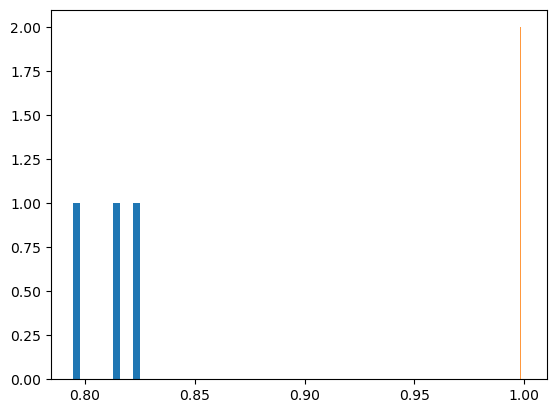

In [49]:
pylab.hist(step_cv), pylab.hist(step_train, alpha=.8)

## Análise de Erro

In [275]:
X_cv_erro = train.iloc[linhas_cv].copy()
X_cv_erro['yhat'] = yhat_cv
X_cv_erro.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,...,Name_Master,Name_Col,Name_Major,Name_Mr,Name_Dr,Name_Don,Name_Sir,Ticket_cat,Ticket_num,yhat
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,...,0,0,0,1,0,0,0,1,17599,1
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,...,0,0,0,1,0,0,0,4,373450,0
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,...,0,0,0,1,0,0,0,8,347742,0
13,14,0,3,"Andersson, Mr. Anders Johan",male,39.0,1,5,347082,31.2750,...,0,0,0,1,0,0,0,13,347082,0
14,15,0,3,"Vestrom, Miss. Hulda Amanda Adolfina",female,14.0,0,0,350406,7.8542,...,0,0,0,0,0,0,0,14,350406,0


In [276]:
erro = X_cv_erro[X_cv_erro['Survived'] != X_cv_erro['yhat']]
erro = erro[['Survived', 'yhat', 'Name', 'Cabin', 'Embarked', 'Sex', 'Sex_b', 'Age', 'Pclass', 'Embarked_S',
             'Embarked_C', 'SibSp', 'Parch', 'Fare', 'Cabin_null',
             'Cabin_C', 'Cabin_E', 'Cabin_G', 'Cabin_D', 'Cabin_A', 'Cabin_B', 'Cabin_F', 'Cabin_T',
             'Name_Miss', 'Name_Mrs', 'Name_Master', 'Name_Col', 'Name_Major', 'Name_Mr', 'Name_Dr', 'Name_Don', 'Name_Sir']]
erro.head()

,Survived,yhat,Name,Cabin,Embarked,Sex,Sex_b,Age,Pclass,Embarked_S,...,Cabin_T,Name_Miss,Name_Mrs,Name_Master,Name_Col,Name_Major,Name_Mr,Name_Dr,Name_Don,Name_Sir
8,1,0,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",NaN,S,female,1,27.0,3,1,...,0,0,1,0,0,0,1,0,0,0
21,1,0,"Beesley, Mr. Lawrence",D56,S,male,0,34.0,2,1,...,0,0,0,0,0,0,1,0,0,0
32,1,0,"Glynn, Miss. Mary Agatha",NaN,Q,female,1,NaN,3,0,...,0,1,0,0,0,0,0,0,0,0
36,1,0,"Mamee, Mr. Hanna",NaN,C,male,0,NaN,3,0,...,0,0,0,0,0,0,1,0,0,0
47,1,0,"O'Driscoll, Miss. Bridget",NaN,Q,female,1,NaN,3,0,...,0,1,0,0,0,0,0,1,0,0


In [277]:
female = erro[erro['Sex_b'] == 1]
male = erro[erro['Sex_b'] == 0]

In [278]:
female.sort_values('Survived')

,Survived,yhat,Name,Cabin,Embarked,Sex,Sex_b,Age,Pclass,Embarked_S,...,Cabin_T,Name_Miss,Name_Mrs,Name_Master,Name_Col,Name_Major,Name_Mr,Name_Dr,Name_Don,Name_Sir
498,0,1,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",C22 C26,S,female,1,25.0,1,1,...,0,0,1,0,0,0,1,0,0,0
297,0,1,"Allison, Miss. Helen Loraine",C22 C26,S,female,1,2.0,1,1,...,0,1,0,0,0,0,0,0,0,0
8,1,0,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",NaN,S,female,1,27.0,3,1,...,0,0,1,0,0,0,1,0,0,0
786,1,0,"Sjoblom, Miss. Anna Sofia",NaN,S,female,1,18.0,3,1,...,0,1,0,0,0,0,0,0,0,0
780,1,0,"Ayoub, Miss. Banoura",NaN,C,female,1,13.0,3,0,...,0,1,0,0,0,0,0,0,0,0
747,1,0,"Sinkkonen, Miss. Anna",NaN,S,female,1,30.0,2,1,...,0,1,0,0,0,0,0,0,0,0
727,1,0,"Mannion, Miss. Margareth",NaN,Q,female,1,NaN,3,0,...,0,1,0,0,0,0,0,0,0,0
612,1,0,"Murphy, Miss. Margaret Jane",NaN,Q,female,1,NaN,3,0,...,0,1,0,0,0,0,0,0,0,0
573,1,0,"Kelly, Miss. Mary",NaN,Q,female,1,NaN,3,0,...,0,1,0,0,0,0,0,0,0,0
427,1,0,"Phillips, Miss. Kate Florence (""Mrs Kate Louis...",NaN,S,female,1,19.0,2,1,...,0,1,1,0,0,0,1,0,0,0


In [279]:
male.sort_values('Survived')

,Survived,yhat,Name,Cabin,Embarked,Sex,Sex_b,Age,Pclass,Embarked_S,...,Cabin_T,Name_Miss,Name_Mrs,Name_Master,Name_Col,Name_Major,Name_Mr,Name_Dr,Name_Don,Name_Sir
21,1,0,"Beesley, Mr. Lawrence",D56,S,male,0,34.00,2,1,...,0,0,0,0,0,0,1,0,0,0
553,1,0,"Leeni, Mr. Fahim (""Philip Zenni"")",NaN,C,male,0,22.00,3,0,...,0,0,0,0,0,0,1,0,0,0
607,1,0,"Daniel, Mr. Robert Williams",NaN,S,male,0,27.00,1,1,...,0,0,0,0,0,0,1,0,0,0
630,1,0,"Barkworth, Mr. Algernon Henry Wilson",A23,S,male,0,80.00,1,1,...,0,0,0,0,0,0,1,0,0,0
632,1,0,"Stahelin-Maeglin, Dr. Max",B50,C,male,0,32.00,1,0,...,0,0,0,0,0,0,0,1,0,0
645,1,0,"Harper, Mr. Henry Sleeper",D33,C,male,0,48.00,1,0,...,0,0,0,0,0,0,1,0,0,0
647,1,0,"Simonius-Blumer, Col. Oberst Alfons",A26,C,male,0,56.00,1,0,...,0,0,0,0,1,0,0,0,0,0
681,1,0,"Hassab, Mr. Hammad",D49,C,male,0,27.00,1,0,...,0,0,0,0,0,0,1,0,0,0
690,1,0,"Dick, Mr. Albert Adrian",B20,S,male,0,31.00,1,1,...,0,0,0,0,0,0,1,0,0,0
701,1,0,"Silverthorne, Mr. Spencer Victor",E24,S,male,0,35.00,1,1,...,0,0,0,0,0,0,1,0,0,0


# Retreinando o Modelo

In [280]:
scaler = StandardScaler()

X = scaler.fit_transform(X)
X_test = scaler.transform(X_test)

In [281]:
model = XGBClassifier(learning_rate=opt.x[4],
                         n_estimators=opt.x[0],
                         max_depth=opt.x[1],
                         min_child_weight=opt.x[2],
                         subsample=opt.x[3],
                         num_parallel_tree=opt.x[5],
                         n_jobs=-1, 
                         random_state=42)
    
model.fit(X, y)

yhat = model.predict(X_test)

yhat

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0,
       1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1,
       1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1,
       0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1,
       1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0,
       1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1,
       0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0,

# Criando o Resultado das Previsões para Importar ao Kaggle

In [282]:
result = pd.Series(yhat.reshape(-1), index=test['PassengerId'], name='Survived')
result

PassengerId
892     0
893     0
894     0
895     0
896     0
       ..
1305    0
1306    1
1307    0
1308    0
1309    0
Name: Survived, Length: 418, dtype: int32

In [283]:
result.to_csv('./yhat/xgboost_model.csv', header=True)